In [9]:
import pandas as pd

df = pd.read_parquet("../data/raw_data_full.parquet")
print(df.head())
df.shape
df.dtypes
df["datetime"] = pd.to_datetime(df["datetime"])
df.dtypes
df.isnull().sum()
df.describe()

              datetime  season  yr  mnth  hr  holiday  weekday  workingday  \
0  2011-01-01 00:00:00       1   0     1   0        0        6           0   
1  2011-01-01 01:00:00       1   0     1   1        0        6           0   
2  2011-01-01 02:00:00       1   0     1   2        0        6           0   
3  2011-01-01 03:00:00       1   0     1   3        0        6           0   
4  2011-01-01 04:00:00       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


,datetime,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 15:41:22.858622,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 22:30:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-02 21:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 06:30:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 23:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


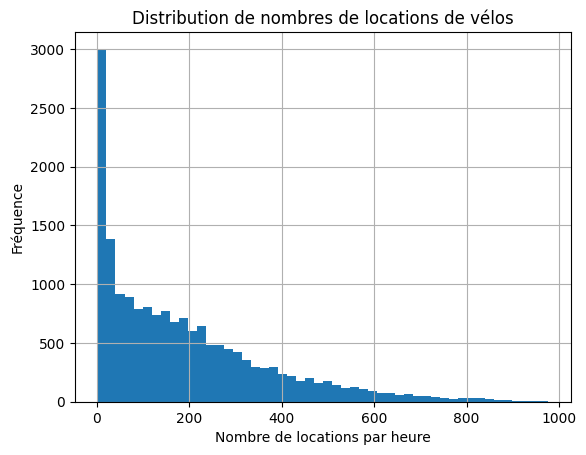

In [4]:
import matplotlib.pyplot as plt

df["cnt"].hist(bins=50)
plt.title("Distribution de nombres de locations de vélos")
plt.xlabel("Nombre de locations par heure")
plt.ylabel("Fréquence")
plt.show()

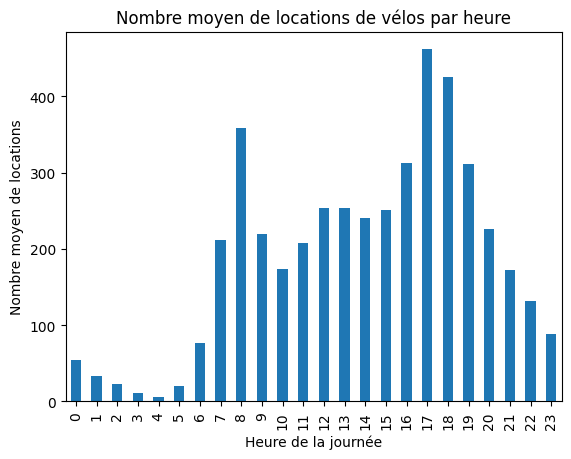

In [8]:
df.groupby("hr")["cnt"].mean().plot(kind="bar")
plt.title("Nombre moyen de locations de vélos par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre moyen de locations")
plt.show()

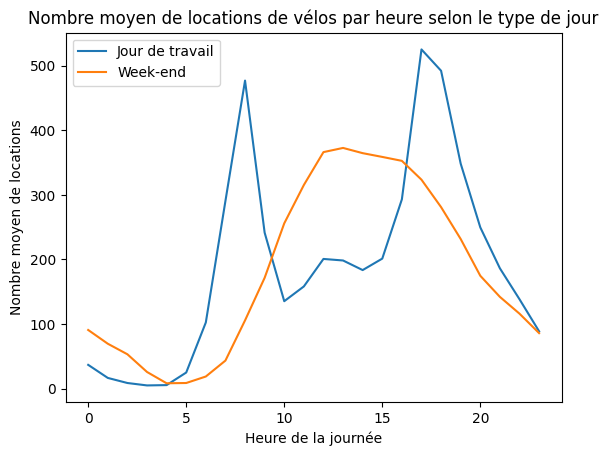

In [10]:
workday = df[df["workingday"] == 1]
workday.groupby("hr")["cnt"].mean().plot(label = "Jour de travail")
weekend = df[df["workingday"] == 0]
weekend.groupby("hr")["cnt"].mean().plot(label = "Week-end")
plt.title("Nombre moyen de locations de vélos par heure selon le type de jour")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre moyen de locations")
plt.legend()
plt.show()

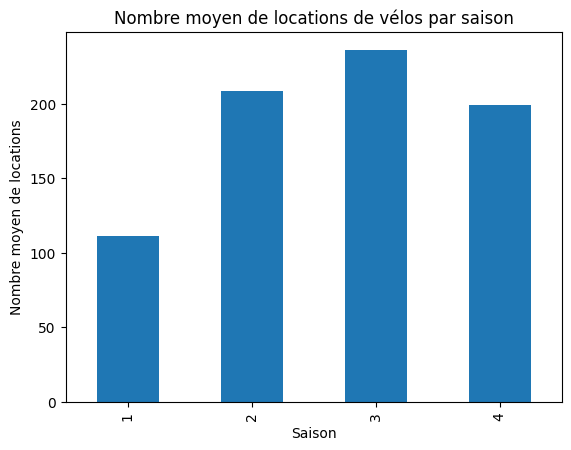

In [ ]:
df.groupby("season")["cnt"].mean().plot(kind="bar")
plt.title("Nombre moyen de locations de vélos par saison")
plt.xlabel("Saison (1= Printemps, 2= Été, 3= Automne, 4= Hiver)")
plt.ylabel("Nombre moyen de locations")
plt.show()

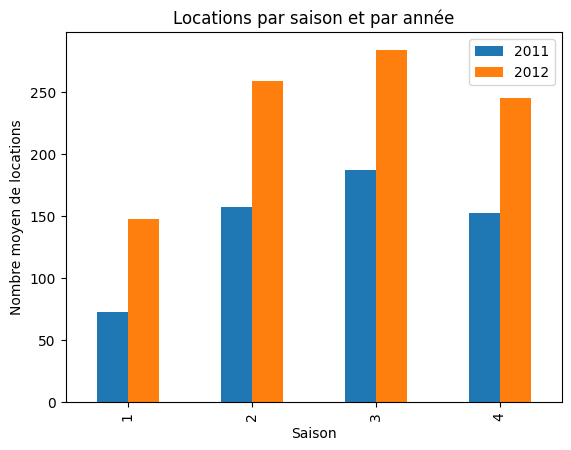

In [12]:
df.groupby(['season', 'yr'])['cnt'].mean().unstack().plot(kind='bar')
plt.title("Locations par saison et par année")
plt.xlabel("Saison")
plt.ylabel("Nombre moyen de locations")
plt.legend(['2011', '2012'])
plt.show()

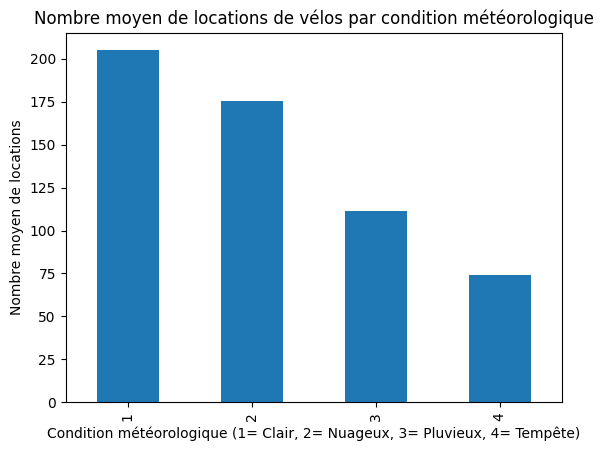

In [13]:
df.groupby("weathersit")["cnt"].mean().plot(kind="bar")
plt.title("Nombre moyen de locations de vélos par condition météorologique")
plt.xlabel("Condition météorologique (1= Clair, 2= Nuageux, 3= Pluvieux, 4= Tempête)")
plt.ylabel("Nombre moyen de locations")
plt.show()